# DataForSEO Topic Graph - DAG Analysis

This notebook analyzes the DataForSEO topic graph as a Directed Acyclic Graph (DAG) using NetworkX.

In [38]:
import json
import networkx as nx
import matplotlib as mpl
import matplotlib.pyplot as plt
from collections import defaultdict

## Load the Topic Graph

In [39]:
# Load the JSON file
#JSON = 'dataforseo-topic-graph.jsonl'
JSON = '../seo-graph-10tools-single.json'

with open(JSON, 'r') as file:
    data = json.load(file)

print(f"Total nodes: {len(data['nodes'])}")
print(f"Root ID: {data.get('root_id', 'N/A')}")

Total nodes: 156
Root ID: 0


## Build NetworkX DiGraph from Topic Data

In [40]:
import networkx as nx
from collections import deque

# Create a directed graph
G = nx.DiGraph()

# Add nodes 
for node_id, node_data in data['nodes'].items():
    G.add_node(
        str(node_id),
        topic=node_data.get('topic', ''),
        metadata=node_data.get('metadata', {})
    )

    # Add edges from parent to children
    for child_id in node_data.get('children', []):
        G.add_edge(str(node_id), str(child_id))

# Compute depth
roots = [n for n in G.nodes if G.in_degree(n) == 0]
for root in roots:
    G.nodes[root]['depth'] = 0
    queue = deque([(root, 0)])

    while queue:
        node, depth = queue.popleft()
        for child in G.successors(node):
            # Avoid overwriting if already set 
            if 'depth' not in G.nodes[child]:
                G.nodes[child]['depth'] = depth + 1
                queue.append((child, depth + 1))

print(f"Graph has {G.number_of_nodes()} nodes and {G.number_of_edges()} edges")


Graph has 156 nodes and 198 edges


## Verify it's a Valid DAG

In [41]:
# Check if it's a DAG
is_dag = nx.is_directed_acyclic_graph(G)
print(f"Is this a valid DAG? {is_dag}")

if not is_dag:
    # Find cycles if any
    try:
        cycles = list(nx.simple_cycles(G))
        print(f"Found {len(cycles)} cycles")
        if cycles:
            print("First cycle:", cycles[0])
    except:
        print("Could not detect cycles")

Is this a valid DAG? True


## Display All Topics

In [42]:
# Display all topics with their properties
print("=" * 100)
for node_id in G.nodes():
    topic = G.nodes[node_id]['topic']
    depth = G.nodes[node_id]['depth']
    children_count = G.out_degree(node_id)  # Number of outgoing edges
    parents_count = G.in_degree(node_id)    # Number of incoming edges
    
    print(f"ID: {node_id:4s} | Depth: {depth} | Parents: {parents_count} | Children: {children_count:2d}")
    print(f"  Topic: {topic}")
    print()

ID: 0    | Depth: 0 | Parents: 0 | Children: 15
  Topic: Generate diverse SEO tasks using 10 core tools calling a single tool


ID: 1    | Depth: 1 | Parents: 1 | Children: 13
  Topic: Understanding Diverse SEO Task Categories

ID: 2    | Depth: 1 | Parents: 1 | Children: 14
  Topic: Key Features of the 10 Core SEO Tools

ID: 3    | Depth: 1 | Parents: 1 | Children: 13
  Topic: Designing the Single Orchestration Tool for SEO Task Management

ID: 4    | Depth: 1 | Parents: 1 | Children:  9
  Topic: Automated Workflow for Generating SEO Tasks

ID: 5    | Depth: 1 | Parents: 1 | Children:  9
  Topic: Benefits and Challenges of Unified SEO Task Generation

ID: 12   | Depth: 1 | Parents: 3 | Children:  5
  Topic: Improved Data Consistency and Reporting Across Tools

ID: 15   | Depth: 1 | Parents: 3 | Children:  5
  Topic: User Adoption and Training Requirements for the Single Tool

ID: 19   | Depth: 1 | Parents: 3 | Children:  5
  Topic: Monitoring and Reporting of Automated SEO Tasks

ID: 

## DAG Analysis - Basic Statistics

In [43]:
# Find root nodes (no incoming edges)
root_nodes = [n for n in G.nodes() if G.in_degree(n) == 0]
print(f"Root nodes: {len(root_nodes)}")
for root in root_nodes:
    print(f"  - {root}: {G.nodes[root]['topic']}")

print()

# Find leaf nodes (no outgoing edges)
leaf_nodes = [n for n in G.nodes() if G.out_degree(n) == 0]
print(f"Leaf nodes: {len(leaf_nodes)}")
print(f"First 10 leaf topics:")
for leaf in leaf_nodes[:10]:
    print(f"  - {leaf}: {G.nodes[leaf]['topic']}")

Root nodes: 1
  - 0: Generate diverse SEO tasks using 10 core tools calling a single tool


Leaf nodes: 125
First 10 leaf topics:
  - 31: Core Components of the Orchestration Tool
  - 32: Scalability and High Availability Design
  - 33: Plugin and Extension Architecture
  - 34: Security Architecture and Mechanisms
  - 35: Integration with External Systems
  - 41: Input Data Types and Validation
  - 42: Output Data Structures and Serialization
  - 43: Parameterization and Dynamic Inputs
  - 44: Error Handling and Fallbacks for I/O
  - 45: Schema Definition and Metadata for I/O


## Topological Sort

In [44]:
# Get topological ordering (valid processing order)
if is_dag:
    topo_order = list(nx.topological_sort(G))
    print(f"Topological order (first 20 nodes):")
    for i, node_id in enumerate(topo_order[:20]):
        print(f"{i+1}. {node_id}: {G.nodes[node_id]['topic'][:80]}...")
else:
    print("Cannot perform topological sort on a graph with cycles")

Topological order (first 20 nodes):
1. 0: Generate diverse SEO tasks using 10 core tools calling a single tool
...
2. 1: Understanding Diverse SEO Task Categories...
3. 2: Key Features of the 10 Core SEO Tools...
4. 3: Designing the Single Orchestration Tool for SEO Task Management...
5. 4: Automated Workflow for Generating SEO Tasks...
6. 5: Benefits and Challenges of Unified SEO Task Generation...
7. 25: Emerging SEO Task Categories: Voice Search, AI, and Local SEO...
8. 21: Detailed Breakdown of On-Page SEO Task Categories...
9. 22: Exploring Off-Page SEO Task Categories and Strategies...
10. 23: Technical SEO Task Categories: Crawling, Indexing, and Performance...
11. 24: Understanding Keyword Research and Content Planning Task Categories...
12. 26: Keyword Research and Analysis Tool Features...
13. 29: Backlink Analysis and Link Building Features...
14. 6: Architecture of the Orchestration Tool...
15. 7: Defining Task Inputs and Outputs for Orchestration...
16. 8: Integration APIs

## Depth Level Analysis

In [45]:
# Group nodes by depth
depth_groups = defaultdict(list)
for node_id in G.nodes():
    depth = G.nodes[node_id]['depth']
    depth_groups[depth].append(node_id)

print("Nodes per depth level:")
for depth in sorted(depth_groups.keys()):
    print(f"  Depth {depth}: {len(depth_groups[depth])} nodes")

print(f"\nMaximum depth: {max(depth_groups.keys())}")

Nodes per depth level:
  Depth 0: 1 nodes
  Depth 1: 15 nodes
  Depth 2: 65 nodes
  Depth 3: 75 nodes

Maximum depth: 3


## Find Ancestors and Descendants

In [46]:
# Example: Find all ancestors and descendants of a specific node
# Change this to any node ID you're interested in
example_node = '1'  # First child of root

if example_node in G.nodes():
    print(f"Analyzing node {example_node}: {G.nodes[example_node]['topic']}")
    print()
    
    # Ancestors (all nodes that can reach this node)
    ancestors = nx.ancestors(G, example_node)
    print(f"Ancestors ({len(ancestors)}):")
    for anc in list(ancestors)[:5]:
        print(f"  - {anc}: {G.nodes[anc]['topic'][:60]}...")
    
    print()
    
    # Descendants (all nodes reachable from this node)
    descendants = nx.descendants(G, example_node)
    print(f"Descendants ({len(descendants)}):")
    for desc in list(descendants)[:5]:
        print(f"  - {desc}: {G.nodes[desc]['topic'][:60]}...")

Analyzing node 1: Understanding Diverse SEO Task Categories

Ancestors (1):
  - 0: Generate diverse SEO tasks using 10 core tools calling a sin...

Descendants (78):
  - 133: Advanced Local SEO Tactics for Businesses...
  - 90: Methods for Dynamic Input Parameter Generation...
  - 153: SERP Rank Tracking Tools...
  - 125: Core Web Vitals and Page Speed...
  - 154: Website Traffic Analysis Tools...


## Find Paths Between Nodes

In [47]:
# Find all paths from root to a leaf node
if root_nodes and leaf_nodes:
    root = root_nodes[0]
    leaf = leaf_nodes[0]
    
    if nx.has_path(G, root, leaf):
        # Get all simple paths
        all_paths = list(nx.all_simple_paths(G, root, leaf))
        print(f"Found {len(all_paths)} path(s) from root '{root}' to leaf '{leaf}'")
        print(f"\nFirst path:")
        for node in all_paths[0]:
            print(f"  → {node}: {G.nodes[node]['topic'][:70]}...")
        
        # Shortest path
        shortest = nx.shortest_path(G, root, leaf)
        print(f"\nShortest path length: {len(shortest)-1} edges")

Found 2 path(s) from root '0' to leaf '31'

First path:
  → 0: Generate diverse SEO tasks using 10 core tools calling a single tool
...
  → 2: Key Features of the 10 Core SEO Tools...
  → 6: Architecture of the Orchestration Tool...
  → 31: Core Components of the Orchestration Tool...

Shortest path length: 3 edges


## Visualize a Subgraph (Limited Depth)

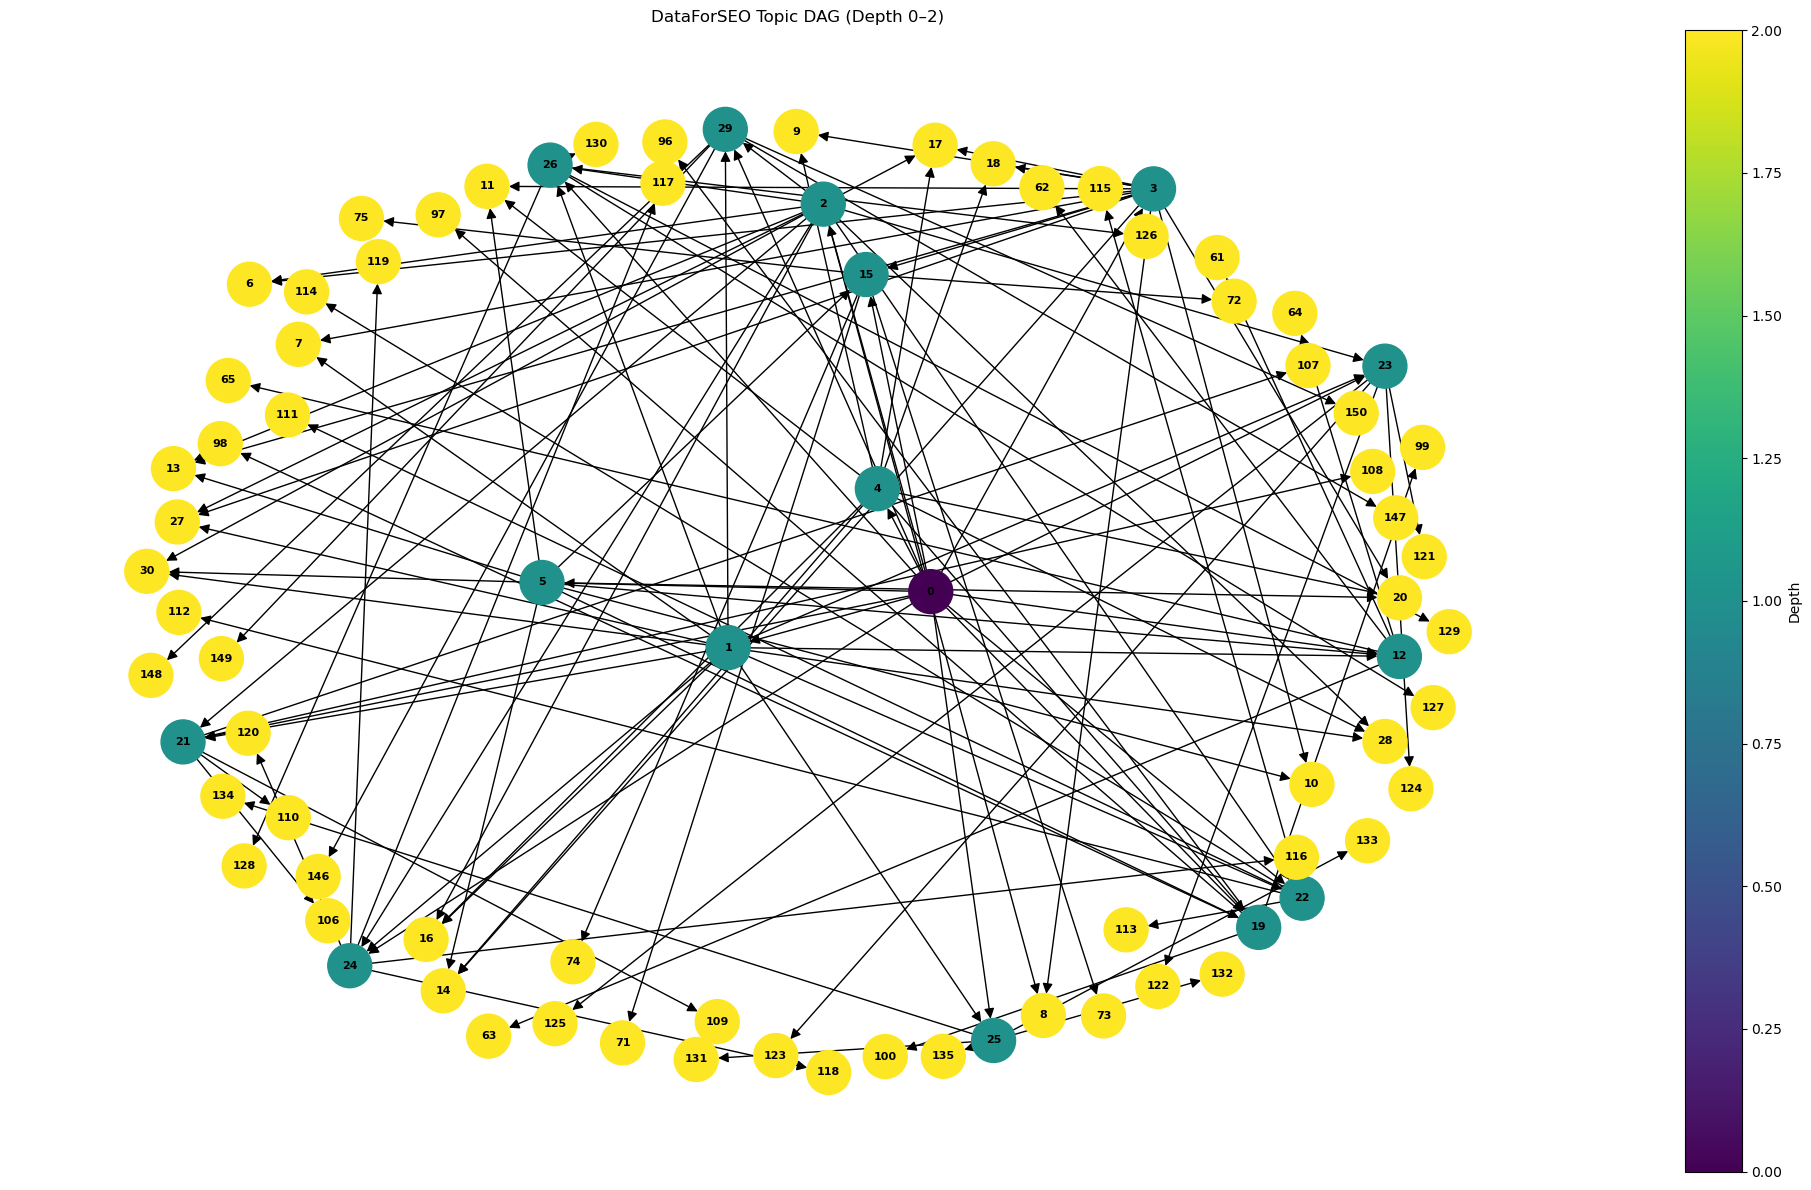

Visualized 81 nodes out of 156 total


In [48]:
# Visualize only nodes up to depth 2 for readability
MAX_DEPTH = 2
subgraph_nodes = [n for n in G.nodes() if G.nodes[n]['depth'] <= MAX_DEPTH]
subG = G.subgraph(subgraph_nodes)

fig, ax = plt.subplots(figsize=(20, 12))

pos = nx.spring_layout(subG, k=2, iterations=50)

# Color nodes by depth
node_colors = [G.nodes[n]['depth'] for n in subG.nodes()]

nx.draw(
    subG,
    pos,
    ax=ax,
    node_color=node_colors,
    cmap=plt.cm.viridis,
    with_labels=True,
    labels={n: n for n in subG.nodes()},
    node_size=1000,
    font_size=8,
    font_weight='bold',
    arrows=True,
    arrowsize=15
)

ax.set_title(f"DataForSEO Topic DAG (Depth 0–{MAX_DEPTH})")

# Compute colorbar
norm = mpl.colors.Normalize(
    vmin=min(node_colors),
    vmax=max(node_colors)
)
sm = mpl.cm.ScalarMappable(cmap=plt.cm.viridis, norm=norm)
sm.set_array([])

fig.colorbar(sm, ax=ax, label='Depth')

plt.tight_layout()
plt.show()

print(f"Visualized {len(subgraph_nodes)} nodes out of {G.number_of_nodes()} total")


## Interactive Visualization with PyVis

In [49]:
from pyvis.network import Network

# Create interactive visualization for limited depth
MAX_DEPTH_INTERACTIVE = 3
subgraph_nodes = [n for n in G.nodes() if G.nodes[n]['depth'] <= MAX_DEPTH_INTERACTIVE]
subG = G.subgraph(subgraph_nodes)

net = Network(height="800px", width="100%", notebook=True, directed=True)
net.barnes_hut()  # Use Barnes-Hut physics for better layout

# Add nodes with hover tooltips
for node in subG.nodes():
    topic = G.nodes[node]['topic']
    depth = G.nodes[node]['depth']
    net.add_node(node, 
                 label=f"{node}",
                 title=f"Depth {depth}: {topic}",
                 level=depth)  # Use depth for hierarchical layout

# Add edges
for u, v in subG.edges():
    net.add_edge(u, v)

# Set hierarchical layout
net.set_options("""
{
  "layout": {
    "hierarchical": {
      "enabled": true,
      "direction": "UD",
      "sortMethod": "directed"
    }
  },
  "physics": {
    "hierarchicalRepulsion": {
      "centralGravity": 0.0
    }
  }
}
""")

net.show("dataforseo_dag_interactive.html")
print(f"Interactive visualization saved to dataforseo_dag_interactive.html")

dataforseo_dag_interactive.html
Interactive visualization saved to dataforseo_dag_interactive.html
